# Cuaderno 10 · Causalidad explicable de extremo a extremo y auditoría ética

### Serie *Inferencia Causal + IA Explicativa* · Capítulo 10 de 10 · **Cierre del recorrido**

> Cuaderno reproducible asociado al artículo divulgativo **«De la correlación a la causa: inteligencia artificial explicable e inferencia causal»**. Datos abiertos; ejecución completa.

---

Llegamos al final. La Sección 1 mostró que la explicabilidad describe el modelo pero no el mundo; la Sección 2 dio el aparato causal para hablar del mundo; el cuaderno 09 las reunió explicando efectos causales. Este capítulo **integra todo de extremo a extremo** sobre el caso guía —un modelo de *scoring* crediticio— y añade la dimensión que faltaba: la **auditoría ética**. Una decisión algorítmica responsable debe responder cuatro preguntas, una por cada herramienta del curso:

1. **¿Por qué?** — explicarla (SHAP, cuaderno 02).
2. **¿Qué cambiar?** — dar recurso accionable (contrafactuales, cuaderno 03).
3. **¿Es causal o un proxy?** — distinguir asociación de causa (cuaderno 04).
4. **¿Es justa?** — auditar equidad y sesgos (este cuaderno).

## Contenido y objetivos

1. **El despliegue responsable** — el caso crediticio y las cuatro preguntas.
2. **Explicar y dar recurso** — SHAP (por qué) + contrafactual (qué cambiar).
3. **Auditoría de equidad de grupo** — paridad demográfica, igualación de *odds*, y el teorema de imposibilidad.
4. **Equidad contrafactual y proxies** — voltear el atributo protegido; detectar y mitigar el uso de *proxies*.
5. **El flujo de extremo a extremo** y el cierre del curso.

**Objetivos.** Integrar explicabilidad, recurso, chequeo causal y auditoría de equidad en una sola tubería; definir y **medir** la (in)equidad de un modelo real; y argumentar una decisión trazable y responsable.

*(Construido por pasos: esta versión incluye las Secciones 1–2.)*

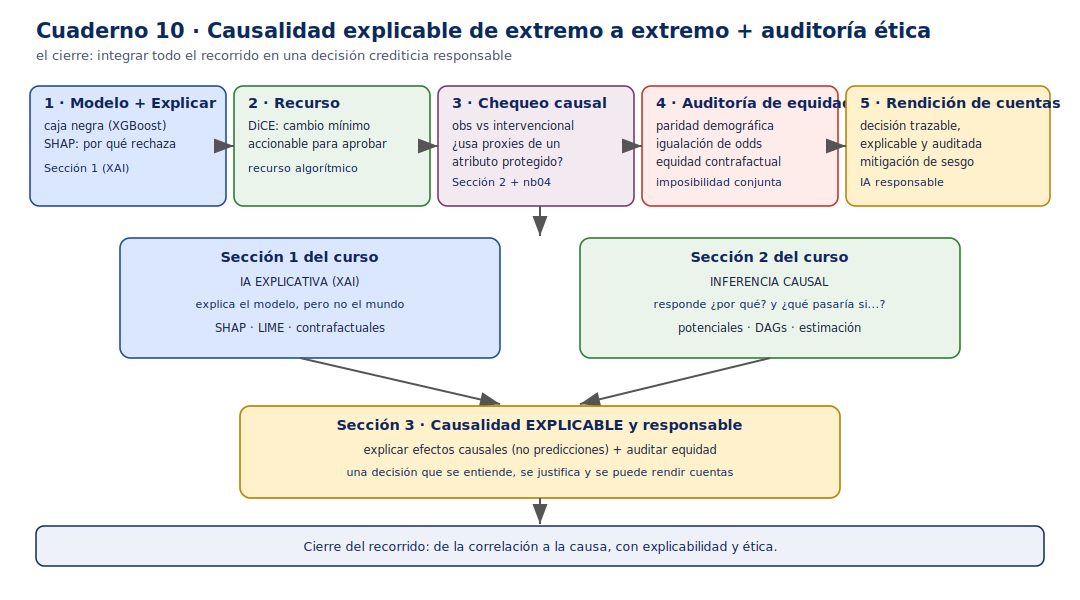

In [1]:
# Diagrama de flujo del cuaderno (se incrusta en la salida)
from pathlib import Path
from IPython.display import SVG, display
_svg = Path('../img/10_flujo.svg')
if not _svg.exists():
    _svg = Path('img/10_flujo.svg')
display(SVG(filename=str(_svg)))

In [2]:
# Configuración y modelo de scoring crediticio (manteniendo 'sexo' como atributo a auditar)
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))
from src.data import load_german_credit

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.figsize": (7, 4.2), "axes.grid": True, "axes.axisbelow": True})

df = load_german_credit()
y = df["riesgo_bueno"]
num = ["duracion_meses", "monto_credito", "tasa_cuota_pct", "residencia_desde",
       "edad", "n_creditos_banco", "n_dependientes"]
Xraw = df.drop(columns=["riesgo", "riesgo_bueno", "estado_personal_sexo"]).copy()   # conserva 'sexo'
Xraw[num] = Xraw[num].astype(float)
cat = [c for c in Xraw.columns if c not in num]
pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat)],
                        remainder="passthrough", verbose_feature_names_out=False)
model = Pipeline([("pre", pre),
                  ("clf", XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                        subsample=0.9, eval_metric="logloss", random_state=RANDOM_STATE))])
X_tr, X_te, y_tr, y_te = train_test_split(Xraw, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
model.fit(X_tr, y_tr)
proba = model.predict_proba(X_te)[:, 1]
print(f"AUC del modelo de scoring = {roc_auc_score(y_te, proba):.3f}")
print(f"variables: {Xraw.shape[1]} (incluye 'sexo' como atributo protegido a auditar)")

AUC del modelo de scoring = 0.766
variables: 20 (incluye 'sexo' como atributo protegido a auditar)


## Sección 1 · El despliegue responsable: cuatro preguntas

Un modelo que decide quién recibe un crédito afecta vidas. Antes de desplegarlo, una organización responsable —y, cada vez más, la regulación— exige responder:

| Pregunta | Herramienta | Cuaderno |
|---|---|---|
| ¿Por qué esta decisión? | explicación (SHAP/LIME) | 02 |
| ¿Qué debería cambiar el solicitante? | contrafactual / recurso | 03 |
| ¿La razón es causal o un *proxy*? | atribución intervencional vs. observacional | 04 |
| ¿La decisión es justa entre grupos? | auditoría de equidad | **10** |

Las tres primeras se desarrollaron en la Sección 1 del curso; la cuarta —y su entrelazamiento con la causalidad— es el corazón de este cierre. El costo de error es **asimétrico** (la matriz oficial penaliza 5× aprobar a un mal pagador) y hay un **atributo protegido** (el sexo): el escenario ideal para una auditoría.

## Sección 2 · Explicar la decisión y ofrecer un recurso

Para un solicitante **rechazado**, la explicación responde *por qué* y el contrafactual *qué cambiar*. Recuperamos ambas herramientas (cuadernos 02–03) sobre este modelo.

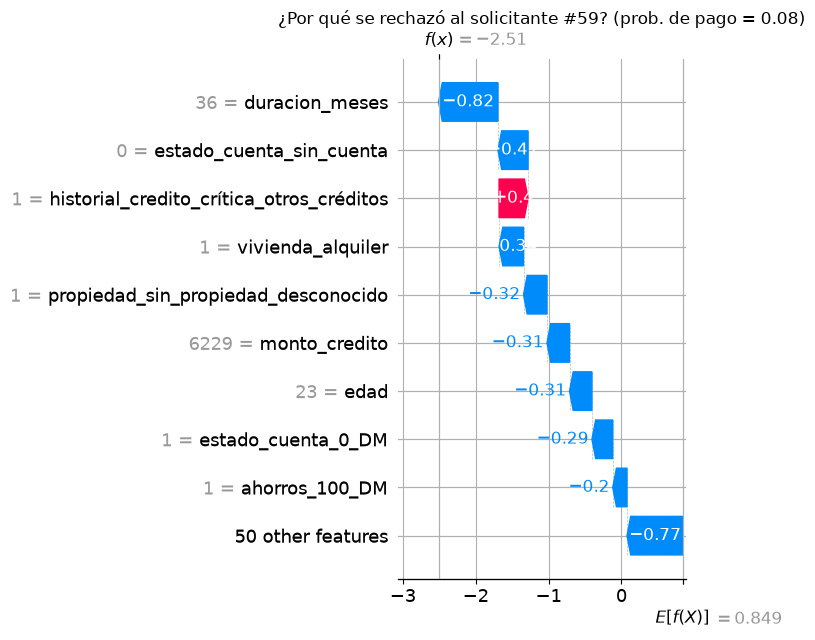

In [3]:
# (a) ¿Por qué? — SHAP local para el solicitante más rechazado
import re
clf = model.named_steps["clf"]; prep = model.named_steps["pre"]
nombres = [re.sub(r"_+", "_", re.sub(r"[^0-9A-Za-zÀ-ſ_]", "_", c)).strip("_")
           for c in prep.get_feature_names_out()]
X_te_enc = np.asarray(prep.transform(X_te))         # numpy: evita la validación de nombres de XGBoost
sv = shap.TreeExplainer(clf)(X_te_enc)
sv.feature_names = nombres
j = int(np.argmin(proba))                           # el más rechazado
shap.plots.waterfall(sv[j], max_display=10, show=False)
plt.title(f"¿Por qué se rechazó al solicitante #{X_te.index[j]}? (prob. de pago = {proba[j]:.2f})")
plt.tight_layout(); plt.show()

In [4]:
# (b) ¿Qué cambiar? — recurso contrafactual con DiCE
import dice_ml
train_df = X_tr.copy(); train_df["riesgo_bueno"] = y_tr.values
d_data = dice_ml.Data(dataframe=train_df, continuous_features=num, outcome_name="riesgo_bueno")
d_model = dice_ml.Model(model=model, backend="sklearn")
dice = dice_ml.Dice(d_data, d_model, method="random")
accionables = ["duracion_meses", "monto_credito", "ahorros", "estado_cuenta", "otros_planes_pago"]
query = X_te.iloc[[j]]
cf = dice.generate_counterfactuals(query, total_CFs=2, desired_class="opposite",
                                   features_to_vary=accionables)
cf_df = cf.cf_examples_list[0].final_cfs_df.reset_index(drop=True)
orig = query.iloc[0]
print(f"Recurso para el solicitante #{X_te.index[j]} (cómo pasar de RECHAZADO a aprobado):\n")
for i, row in cf_df.drop(columns=["riesgo_bueno"]).iterrows():
    camb = {c: (orig[c], row[c]) for c in Xraw.columns if str(orig[c]) != str(row[c])}
    print(f"  Opción {i+1}:  " + "   |   ".join(f"{c}: {a} → {b}" for c, (a, b) in camb.items()))

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 12.58it/s]

Recurso para el solicitante #59 (cómo pasar de RECHAZADO a aprobado):

  Opción 1:  estado_cuenta: < 0 DM → sin cuenta   |   monto_credito: 6229.0 → 3638.3
  Opción 2:  estado_cuenta: < 0 DM → >= 200 DM   |   monto_credito: 6229.0 → 574.8


> **Observación 2.1.** SHAP dice *por qué* (qué variables empujaron el rechazo) y el contrafactual dice *qué cambiar* (un recurso accionable). Pero ambos describen el **modelo**: el cuaderno 04 advirtió que esas atribuciones pueden apoyarse en **proxies** correlacionados —incluido un *proxy* de un atributo protegido—. Por eso la explicación no basta: hay que **auditar la equidad**, lo que hacemos a continuación.

## Sección 3 · Auditoría de equidad de grupo

Una decisión puede ser precisa y, aun así, **injusta** entre grupos. La equidad algorítmica no es un único concepto: hay varias definiciones, y son **incompatibles** entre sí.

> **Definición 3.1 (paridad demográfica).** La tasa de decisiones positivas es igual entre grupos: $P(\hat Y{=}1\mid G{=}a)=P(\hat Y{=}1\mid G{=}b)$. (Igual tasa de aprobación.)

> **Definición 3.2 (igualdad de oportunidad / *equalized odds*).** *Igualdad de oportunidad*: igual **tasa de verdaderos positivos** (TPR) entre grupos. *Equalized odds*: igual TPR **e** igual tasa de falsos positivos (FPR).

> **Definición 3.3 (calibración / paridad predictiva).** Entre los aprobados, la proporción de buenos pagadores es igual en ambos grupos: $P(Y{=}1\mid \hat Y{=}1, G{=}a)=P(Y{=}1\mid \hat Y{=}1, G{=}b)$.

> **Teorema 3.1 (imposibilidad de la equidad; Chouldechova, 2017; Kleinberg, Mullainathan & Raghavan, 2017).** Si las **tasas base** difieren entre grupos ($P(Y{=}1\mid G{=}a)\neq P(Y{=}1\mid G{=}b)$) y el clasificador no es perfecto, **no** puede satisfacer a la vez la **calibración**, la **igualdad de TPR** y la **igualdad de FPR**. Hay que **elegir** qué criterio priorizar; no existe el modelo "justo" en todos los sentidos.

In [5]:
# Auditoría: métricas de equidad por sexo (umbral 0.5)
s = X_te["sexo"].values
dec = (proba >= 0.5).astype(int)
print(f"{'grupo':7s} {'n':>4} {'base P(bueno)':>13} {'aprobación':>11} {'TPR':>6} {'FPR':>6} {'precisión':>10}")
metr = {}
for g in ["hombre", "mujer"]:
    m = s == g; yy = y_te[m].values; aa = dec[m]
    base = yy.mean(); aprob = aa.mean()
    tpr = aa[yy == 1].mean(); fpr = aa[yy == 0].mean()
    prec = yy[aa == 1].mean() if aa.sum() else np.nan          # paridad predictiva
    metr[g] = dict(base=base, aprob=aprob, tpr=tpr, fpr=fpr, prec=prec)
    print(f"{g:7s} {m.sum():4d} {base:13.2f} {aprob:11.2f} {tpr:6.2f} {fpr:6.2f} {prec:10.2f}")
print(f"\nbrecha de paridad demográfica = {metr['hombre']['aprob']-metr['mujer']['aprob']:+.3f}")
print(f"brecha de TPR (oportunidad)   = {metr['hombre']['tpr']-metr['mujer']['tpr']:+.3f}")
print(f"diferencia de tasas base      = {metr['hombre']['base']-metr['mujer']['base']:+.3f}  (≠ 0 ⇒ aplica el Teorema 3.1)")

grupo      n base P(bueno)  aprobación    TPR    FPR  precisión
hombre   204          0.72        0.78   0.86   0.56       0.80
mujer     96          0.66        0.77   0.89   0.55       0.76

brecha de paridad demográfica = +0.009
brecha de TPR (oportunidad)   = -0.025
diferencia de tasas base      = +0.064  (≠ 0 ⇒ aplica el Teorema 3.1)


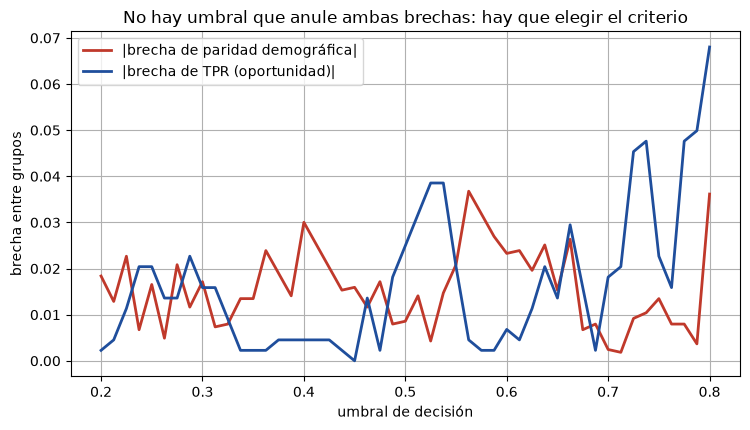

mínimo de cada brecha en el barrido: paridad=0.002, TPR=0.000 (no se anulan en el mismo umbral)


In [6]:
# Ilustración del Teorema 3.1: ningún umbral anula a la vez las dos brechas
ths = np.linspace(0.2, 0.8, 49)
def brechas(thr):
    d = (proba >= thr).astype(int)
    g_ap, g_tpr = {}, {}
    for g in ["hombre", "mujer"]:
        m = s == g; yy = y_te[m].values; aa = d[m]
        g_ap[g] = aa.mean(); g_tpr[g] = aa[yy == 1].mean() if (yy == 1).any() else np.nan
    return abs(g_ap["hombre"] - g_ap["mujer"]), abs(g_tpr["hombre"] - g_tpr["mujer"])
brecha_par = [brechas(t)[0] for t in ths]
brecha_tpr = [brechas(t)[1] for t in ths]
plt.figure(figsize=(7.6, 4.4))
plt.plot(ths, brecha_par, "-", color="#c0392b", lw=2, label="|brecha de paridad demográfica|")
plt.plot(ths, brecha_tpr, "-", color="#1f4e9c", lw=2, label="|brecha de TPR (oportunidad)|")
plt.xlabel("umbral de decisión"); plt.ylabel("brecha entre grupos")
plt.title("No hay umbral que anule ambas brechas: hay que elegir el criterio")
plt.legend(); plt.tight_layout(); plt.show()
print("mínimo de cada brecha en el barrido:",
      f"paridad={min(brecha_par):.3f}, TPR={min(brecha_tpr):.3f} (no se anulan en el mismo umbral)")

> **Observación 3.1.** En agregado, este modelo parece **casi equilibrado**: la brecha de paridad demográfica es pequeña. Pero las **tasas base difieren** (≈0.72 vs 0.66), de modo que —por el Teorema 3.1— mejorar un criterio empeora otro: el barrido de umbral muestra que **ninguna decisión anula a la vez** la brecha de paridad y la de oportunidad. La equidad no es un botón que se activa; es una **elección de valores** que debe declararse y justificarse. Y, como veremos, las métricas de grupo pueden ocultar inequidad a nivel **individual**.

## Sección 4 · Equidad contrafactual y *proxies*: aquí se reúnen causalidad y ética

Las métricas de grupo (Sección 3) pueden verse equilibradas y, aun así, el modelo tratar **distinto a un individuo** según su atributo protegido. La pregunta causal es: *¿cambiaría la decisión si esta persona hubiera tenido otro sexo, con todo lo demás propagado por sus mecanismos?*

> **Definición 4.1 (equidad contrafactual; Kusner et al., 2017).** Una decisión $\hat Y$ es *contrafactualmente justa* respecto de un atributo protegido $A$ si, para cada individuo, su valor es el mismo en el mundo **real** y en el **contrafactual** donde $A$ toma otro valor (propagando el cambio por el modelo causal): $\hat Y_{A\leftarrow a}(x)=\hat Y_{A\leftarrow a'}(x)$. Es una afirmación **causal** (usa el operador del cuaderno 06), no estadística.

In [7]:
# Equidad contrafactual: voltear el sexo (con lo demás igual) y ver qué decisiones cambian
Xcf = X_te.copy()
Xcf["sexo"] = Xcf["sexo"].map({"hombre": "mujer", "mujer": "hombre"})
dec_cf = (model.predict_proba(Xcf)[:, 1] >= 0.5).astype(int)
cambia = dec != dec_cf
print(f"Equidad contrafactual (modelo CON sexo):")
print(f"  decisiones que CAMBIAN al voltear el sexo = {cambia.mean():.1%}  ({cambia.sum()} de {len(dec)})")
print(f"  => el modelo NO es contrafactualmente justo: usa el sexo directamente.")

Equidad contrafactual (modelo CON sexo):
  decisiones que CAMBIAN al voltear el sexo = 3.0%  (9 de 300)
  => el modelo NO es contrafactualmente justo: usa el sexo directamente.


AUC con sexo   = 0.766


AUC ciego      = 0.763   (apenas cambia: el sexo no aporta casi exactitud)


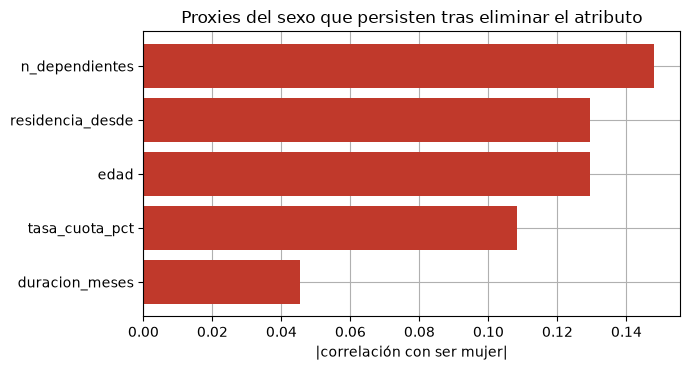

proxies principales: {'n_dependientes': np.float64(0.15), 'residencia_desde': np.float64(0.13), 'edad': np.float64(0.13), 'tasa_cuota_pct': np.float64(0.11), 'duracion_meses': np.float64(0.05)}


In [8]:
# Mitigación 1: 'equidad por desconocimiento' — modelo CIEGO al sexo (y su costo en exactitud)
from sklearn.metrics import roc_auc_score
cols_blind = [c for c in X_tr.columns if c != "sexo"]
cat_b = [c for c in cols_blind if c not in num]
pre_b = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_b)],
                          remainder="passthrough", verbose_feature_names_out=False)
model_blind = Pipeline([("pre", pre_b),
                        ("clf", XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                              subsample=0.9, eval_metric="logloss", random_state=RANDOM_STATE))])
model_blind.fit(X_tr[cols_blind], y_tr)
auc_full = roc_auc_score(y_te, proba)
auc_blind = roc_auc_score(y_te, model_blind.predict_proba(X_te[cols_blind])[:, 1])
print(f"AUC con sexo   = {auc_full:.3f}")
print(f"AUC ciego      = {auc_blind:.3f}   (apenas cambia: el sexo no aporta casi exactitud)")

# Mitigación 2 (incompleta): los PROXIES del sexo siguen presentes
sx = (X_te["sexo"].values == "mujer").astype(int)
proxies = {c: abs(np.corrcoef(X_te[c].values, sx)[0, 1]) for c in num}
top = dict(sorted(proxies.items(), key=lambda z: -z[1])[:5])
plt.figure(figsize=(7, 3.8))
plt.barh(list(top)[::-1], list(top.values())[::-1], color="#c0392b")
plt.xlabel("|correlación con ser mujer|"); plt.title("Proxies del sexo que persisten tras eliminar el atributo")
plt.tight_layout(); plt.show()
print("proxies principales:", {c: round(v, 2) for c, v in top.items()})

> **Observación 4.1 (donde se reúnen las dos secciones del curso).** Quitar el atributo protegido —*equidad por desconocimiento*— **restaura la equidad contrafactual directa** y casi no cuesta exactitud ($0.766\to0.763$): el sexo no aporta poder predictivo legítimo. Pero es **insuficiente**: persisten **proxies** (n.º de dependientes, edad…) correlacionados con el sexo, por los que el modelo podría discriminar indirectamente. Decidir qué proxies son *legítimos* (relacionados causalmente con el riesgo) y cuáles son **discriminación encubierta** **no** se resuelve con estadística: requiere el **modelo causal** —los caminos de $A$ a $\hat Y$ del cuaderno 06—. Aquí, por fin, la **inferencia causal** y la **explicabilidad** se vuelven indispensables *juntas* para una decisión justa.

## Sección 5 · Mitigación II: post-procesamiento y la frontera exactitud–equidad

La «equidad por desconocimiento» (Sección 4) elimina el uso directo del atributo pero no controla las brechas de grupo. El **post-procesamiento** ajusta el **umbral por grupo** para imponer un criterio elegido.

> **Definición 5.1 (post-procesamiento por igualdad de oportunidad; Hardt et al., 2016).** Dado el puntaje $\hat s(x)$, se eligen umbrales por grupo $t_a$ tales que la tasa de verdaderos positivos se iguale: $\;\mathrm{TPR}_a=P(\hat s>t_a\mid Y{=}1,A{=}a)\;$ igual para todo $a$. Análogamente, igualar la **tasa de aprobación** impone paridad demográfica.

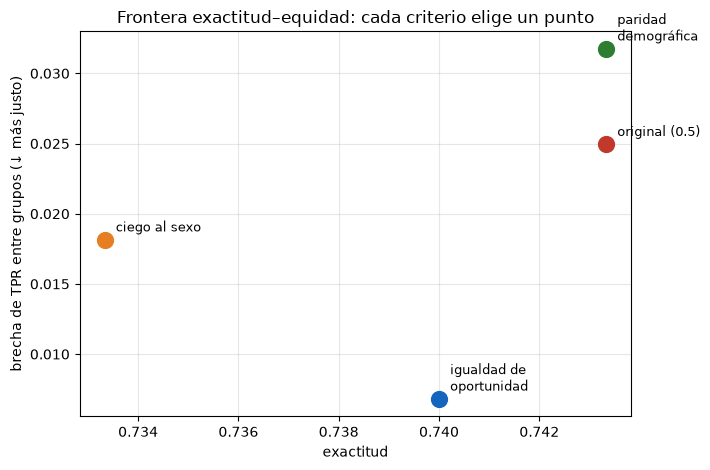

  original (0.5)           exactitud=0.743 | brecha TPR=0.025 | brecha aprob=0.009
  ciego al sexo            exactitud=0.733 | brecha TPR=0.018 | brecha aprob=0.013
  igualdad de oportunidad  exactitud=0.740 | brecha TPR=0.007 | brecha aprob=0.036
  paridad demográfica      exactitud=0.743 | brecha TPR=0.032 | brecha aprob=0.001


In [9]:
# Cuatro estrategias sobre el plano exactitud–equidad
g = X_te["sexo"].values
proba_blind = model_blind.predict_proba(X_te[cols_blind])[:, 1]

def metricas(dec_v, grp=g):
    acc = (dec_v == y_te.values).mean()
    def tpr(a):
        m = (grp == a) & (y_te.values == 1); return dec_v[m].mean()
    def apr(a):
        m = (grp == a); return dec_v[m].mean()
    return acc, abs(tpr("hombre") - tpr("mujer")), abs(apr("hombre") - apr("mujer"))

def thr_tpr(prob, a, target):           # umbral que da TPR=target en el grupo a
    m = (g == a) & (y_te.values == 1); ps = np.sort(prob[m])[::-1]
    return ps[int(np.clip(round(target * len(ps)), 1, len(ps))) - 1]
def thr_apr(prob, a, target):           # umbral que da tasa de aprobación=target en a
    m = (g == a); ps = np.sort(prob[m])[::-1]
    return ps[int(np.clip(round(target * len(ps)), 1, len(ps))) - 1]

dec_orig = (proba >= 0.5).astype(int)
dec_blind = (proba_blind >= 0.5).astype(int)
# igualdad de oportunidad: TPR común = 0.85
t_eo = {a: thr_tpr(proba, a, 0.85) for a in ["hombre", "mujer"]}
dec_eo = np.where(g == "hombre", proba >= t_eo["hombre"], proba >= t_eo["mujer"]).astype(int)
# paridad demográfica: tasa de aprobación común = 0.77
t_dp = {a: thr_apr(proba, a, 0.77) for a in ["hombre", "mujer"]}
dec_dp = np.where(g == "hombre", proba >= t_dp["hombre"], proba >= t_dp["mujer"]).astype(int)

estr = {"original (0.5)": dec_orig, "ciego al sexo": dec_blind,
        "igualdad de\noportunidad": dec_eo, "paridad\ndemográfica": dec_dp}
res = {k: metricas(v) for k, v in estr.items()}
fig, ax = plt.subplots(figsize=(7.2, 4.8))
col = {"original (0.5)": "#c0392b", "ciego al sexo": "#e67e22",
       "igualdad de\noportunidad": "#1565c0", "paridad\ndemográfica": "#2e7d32"}
for k, (acc, gtpr, gapr) in res.items():
    ax.scatter(acc, gtpr, s=130, color=col[k], zorder=3)
    ax.annotate(k, (acc, gtpr), textcoords="offset points", xytext=(8, 6), fontsize=9)
ax.set_xlabel("exactitud"); ax.set_ylabel("brecha de TPR entre grupos (↓ más justo)")
ax.set_title("Frontera exactitud–equidad: cada criterio elige un punto")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
for k, (acc, gtpr, gapr) in res.items():
    print(f"  {k.replace(chr(10),' '):24s} exactitud={acc:.3f} | brecha TPR={gtpr:.3f} | brecha aprob={gapr:.3f}")

> **Observación 5.1.** El post-procesamiento **mueve la decisión por la frontera**, no la elimina: igualar la TPR reduce la brecha de oportunidad a costa de algo de exactitud y de cambiar las tasas de aprobación; igualar la aprobación (paridad demográfica) anula la brecha de aprobación pero no la de TPR. Es la lectura operativa del **Teorema 3.1**: no hay un punto que optimice todo a la vez; la organización debe **elegir y justificar** el criterio, y el método solo lo implementa.

## Sección 6 · ¿Causa o proxy? El do-SHAP como diagnóstico de auditoría

El cuaderno 04 mostró que la atribución **observacional** de SHAP puede inflarse por correlación. La misma herramienta sirve aquí como diagnóstico: si la importancia de una variable cae al pasar a la versión **intervencional**, parte de ella era prestada por correlación (posible *proxy*).

> **Definición 6.1 (SHAP observacional vs intervencional).** El SHAP *observacional* (condicional, `tree_path_dependent`) respeta la dependencia entre variables; el *intervencional* (marginal, con fondo de referencia) rompe esa dependencia —emula el operador $\mathrm{do}$ del cuaderno 06—. Su **cociente** $\phi_{\text{int}}/\phi_{\text{obs}}$ por variable revela cuánta atribución es correlacional.

Background dataset has 150 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=150 when initializing the masker.


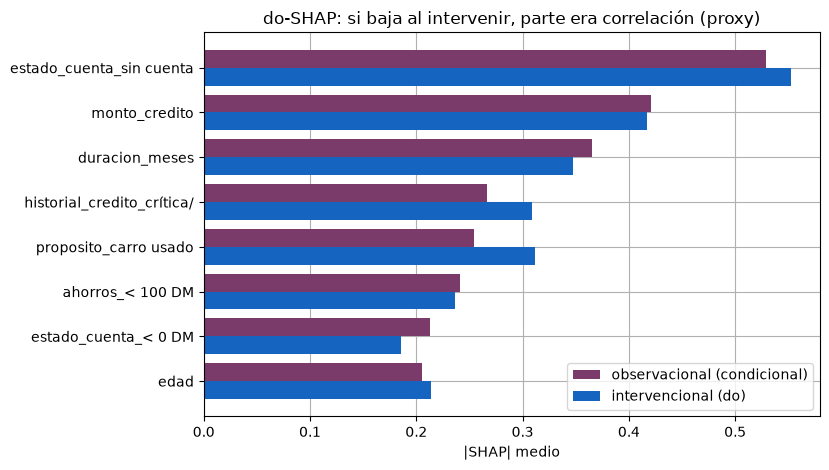

  estado_cuenta_sin cuenta   obs=0.529 int=0.552 ratio=1.04
  monto_credito              obs=0.421 int=0.417 ratio=0.99
  duracion_meses             obs=0.365 int=0.348 ratio=0.95
  historial_credito_crítica/ obs=0.266 int=0.308 ratio=1.16  <- gana al intervenir
  proposito_carro usado      obs=0.255 int=0.312 ratio=1.22  <- gana al intervenir
  ahorros_< 100 DM           obs=0.241 int=0.236 ratio=0.98
  estado_cuenta_< 0 DM       obs=0.213 int=0.186 ratio=0.87  <- baja (correlación)
  edad                       obs=0.205 int=0.214 ratio=1.04


In [10]:
# do-SHAP sobre el modelo de crédito: observacional vs intervencional
import shap
pre = model.named_steps["pre"]; clf = model.named_steps["clf"]
nombres = list(pre.get_feature_names_out())
Xt_tr = np.asarray(pre.transform(X_tr)); Xt_te = np.asarray(pre.transform(X_te))
phi_obs = np.abs(shap.TreeExplainer(clf, feature_perturbation="tree_path_dependent")
                 .shap_values(Xt_te[:300])).mean(0)
phi_int = np.abs(shap.TreeExplainer(clf, data=Xt_tr[:150], feature_perturbation="interventional")
                 .shap_values(Xt_te[:300])).mean(0)
imp = (pd.DataFrame({"f": nombres, "obs": phi_obs, "int": phi_int})
       .sort_values("obs", ascending=False).head(8).iloc[::-1])
yy = np.arange(len(imp)); h = 0.4
plt.figure(figsize=(8.4, 4.8))
plt.barh(yy + h/2, imp["obs"], height=h, label="observacional (condicional)", color="#7a3b6b")
plt.barh(yy - h/2, imp["int"], height=h, label="intervencional (do)", color="#1565c0")
plt.yticks(yy, [s[:26] for s in imp["f"]]); plt.xlabel("|SHAP| medio")
plt.title("do-SHAP: si baja al intervenir, parte era correlación (proxy)")
plt.legend(); plt.tight_layout(); plt.show()
imp["ratio"] = imp["int"] / (imp["obs"] + 1e-9)
for _, r in imp.iloc[::-1].iterrows():
    flag = "  <- gana al intervenir" if r["ratio"] > 1.12 else ("  <- baja (correlación)" if r["ratio"] < 0.9 else "")
    print(f"  {r['f'][:26]:26s} obs={r['obs']:.3f} int={r['int']:.3f} ratio={r['ratio']:.2f}{flag}")

> **Observación 6.1.** En este modelo los cocientes están **cerca de 1**: las atribuciones son bastante estables entre la versión observacional y la intervencional, señal de que su importancia **no** es mayormente prestada por correlación. Algunas (propósito, historial de crédito) **ganan** al intervenir —su peso observacional estaba algo enmascarado por otras variables—. El contraste con el cuaderno 04, donde el *proxy* inflaba la atribución hasta tres veces, ilustra el valor del diagnóstico: el mismo cálculo que allí delató un *proxy* aquí **respalda** que las explicaciones del modelo son razonablemente causales. No es garantía —es una verificación que toda auditoría responsable debería ejecutar.

## Sección 7 · Equidad contrafactual por construcción (Kusner)

La Sección 4 mostró que el modelo usa el sexo directamente; la Sección 5, que igualar métricas de grupo no lo evita. La equidad **contrafactual** exige más: que la decisión no cambie en el mundo donde el individuo tuvo otro sexo, **propagando** ese cambio por los mecanismos causales. Para lograrlo hace falta un **modelo causal**.

Postulamos un DAG ilustrativo en el que el sexo influye —por vías sociales— en variables como la edad, el monto solicitado o el número de dependientes:

$$ \text{sexo}\;\longrightarrow\;\{\text{duración, monto, edad, n.º créditos, n.º dependientes}\}\;\longrightarrow\;\hat Y. $$

> **Definición 7.1 (predictor contrafactualmente justo; Kusner et al., 2017).** Un predictor es contrafactualmente justo si usa **solo variables que no son descendientes** del atributo protegido $A$ en el DAG. Así, intervenir sobre $A$ —y propagar a sus descendientes— no altera la predicción.

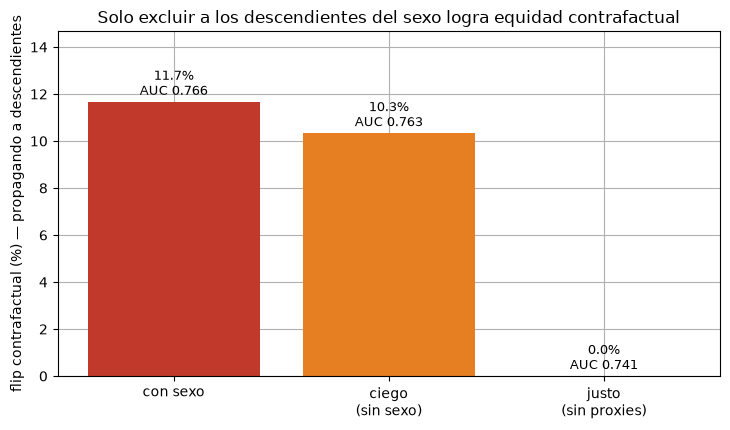

descendientes (proxies) excluidos: ['duracion_meses', 'monto_credito', 'edad', 'n_creditos_banco', 'n_dependientes']
  con sexo           flip=11.7%  AUC=0.766
  ciego (sin sexo)   flip=10.3%  AUC=0.763
  justo (sin proxies) flip=0.0%  AUC=0.741


In [11]:
# Tres modelos: con sexo, ciego (sin sexo) y justo (sin sexo NI sus descendientes/proxies)
sx_tr = (X_tr["sexo"] == "mujer").astype(int)
desc = [c for c in num if abs(np.corrcoef(X_tr[c].values, sx_tr)[0, 1]) >= 0.08]   # descendientes de sexo

def _fit(cols):
    cat = [c for c in cols if c not in num]
    pr = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat)],
                           remainder="passthrough", verbose_feature_names_out=False)
    return Pipeline([("pre", pr), ("clf", XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                     subsample=0.9, eval_metric="logloss", random_state=RANDOM_STATE))])
faircols = [c for c in X_tr.columns if c != "sexo" and c not in desc]
model_fair = _fit(faircols).fit(X_tr[faircols], y_tr)

# SCM lineal sexo -> descendientes: al voltear el sexo, se desplaza cada proxy por la diferencia entre grupos
mean_by = {c: {grp: X_tr.loc[X_tr["sexo"] == grp, c].mean() for grp in ["hombre", "mujer"]} for c in desc}
def make_cf(Xf):
    Xcf = Xf.copy(); Xcf["sexo"] = Xcf["sexo"].map({"hombre": "mujer", "mujer": "hombre"})
    for c in desc:
        shift = Xf["sexo"].map(lambda s: mean_by[c]["mujer" if s == "hombre" else "hombre"] - mean_by[c][s])
        Xcf[c] = Xf[c] + shift.values
    return Xcf
Xcf_prop = make_cf(X_te)

mods = {"con sexo": (model, list(X_te.columns)), "ciego\n(sin sexo)": (model_blind, cols_blind),
        "justo\n(sin proxies)": (model_fair, faircols)}
flips, aucs = {}, {}
for nm, (m, cols) in mods.items():
    d0 = (m.predict_proba(X_te[cols])[:, 1] >= 0.5).astype(int)
    d1 = (m.predict_proba(Xcf_prop[cols])[:, 1] >= 0.5).astype(int)
    flips[nm] = (d0 != d1).mean() * 100; aucs[nm] = roc_auc_score(y_te, m.predict_proba(X_te[cols])[:, 1])

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ks = list(mods); bars = ax.bar(ks, [flips[k] for k in ks], color=["#c0392b", "#e67e22", "#2e7d32"])
ax.set_ylabel("flip contrafactual (%) — propagando a descendientes")
ax.set_title("Solo excluir a los descendientes del sexo logra equidad contrafactual")
for k, b in zip(ks, bars):
    ax.text(b.get_x() + b.get_width()/2, flips[k] + 0.3, f"{flips[k]:.1f}%\nAUC {aucs[k]:.3f}",
            ha="center", fontsize=9)
plt.ylim(0, max(flips.values()) + 3); plt.tight_layout(); plt.show()
print("descendientes (proxies) excluidos:", desc)
for k in ks:
    print(f"  {k.replace(chr(10),' '):18s} flip={flips[k]:.1f}%  AUC={aucs[k]:.3f}")

> **Observación 7.1.** El modelo **ciego** al sexo sigue siendo contrafactualmente **injusto** (flip $\approx 10\%$, apenas por debajo del 11.7 % del modelo con sexo): los *proxies* propagan el atributo. Solo el predictor que excluye **todos los descendientes** del sexo alcanza un flip del **0 %** —contrafactualmente justo por construcción—, pero a un costo real de exactitud ($\text{AUC }0.766\to0.741$). La lección definitiva del curso: **qué** variables descartar no lo decide la estadística, sino el **DAG**; sin el modelo causal, la «equidad por desconocimiento» es una ilusión.

## Sección 8 · Equidad del recurso: ¿es igual de difícil revertir un rechazo?

Un sistema puede ser justo en los **resultados** y, aun así, repartir de forma desigual el **esfuerzo** de revertir una decisión adversa. El recurso (cuaderno 03) también se audita.

> **Definición 8.1 (equidad del recurso; Ustun et al., 2019).** El *recurso* es el cambio accionable mínimo que revierte una decisión adversa. Es **equitativo** si su costo es similar entre grupos. Aproximamos el esfuerzo por el déficit de puntaje $0.5-\hat s(x)$ entre los rechazados: cuánto debe subir el puntaje para alcanzar la aprobación.

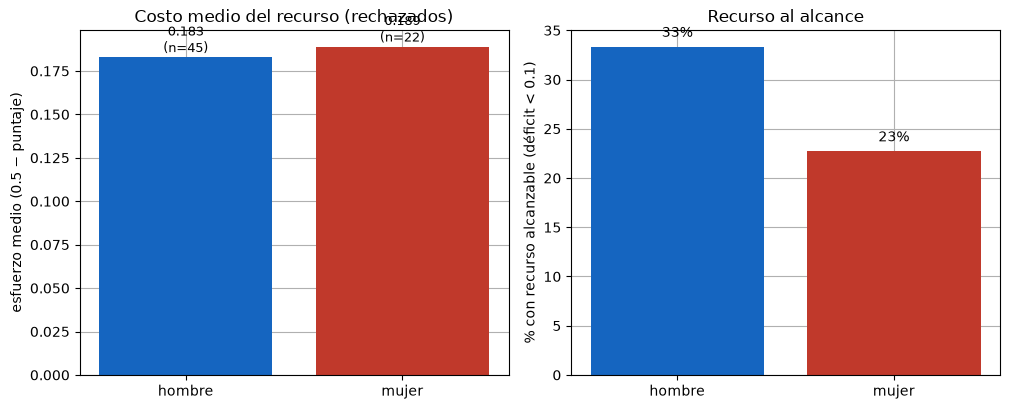

  hombre: rechazados=45 | esfuerzo medio=0.183 | alcanzable(<0.1)=33%
  mujer: rechazados=22 | esfuerzo medio=0.189 | alcanzable(<0.1)=23%


In [12]:
# Esfuerzo de recurso entre los rechazados, por grupo
proba_f = model.predict_proba(X_te)[:, 1]; g = X_te["sexo"].values; rej = proba_f < 0.5
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.2, 4.2))
grupos = ["hombre", "mujer"]; colores = ["#1565c0", "#c0392b"]
esf = {grp: (0.5 - proba_f)[rej & (g == grp)] for grp in grupos}
a1.bar(grupos, [esf[grp].mean() for grp in grupos], color=colores)
a1.set_ylabel("esfuerzo medio (0.5 − puntaje)"); a1.set_title("Costo medio del recurso (rechazados)")
for i, grp in enumerate(grupos):
    a1.text(i, esf[grp].mean() + 0.003, f"{esf[grp].mean():.3f}\n(n={len(esf[grp])})", ha="center", fontsize=9)
a2.bar(grupos, [(esf[grp] < 0.1).mean() * 100 for grp in grupos], color=colores)
a2.set_ylabel("% con recurso alcanzable (déficit < 0.1)"); a2.set_title("Recurso al alcance")
for i, grp in enumerate(grupos):
    a2.text(i, (esf[grp] < 0.1).mean() * 100 + 1, f"{(esf[grp] < 0.1).mean():.0%}", ha="center", fontsize=10)
plt.tight_layout(); plt.show()
for grp in grupos:
    print(f"  {grp}: rechazados={len(esf[grp])} | esfuerzo medio={esf[grp].mean():.3f} | "
          f"alcanzable(<0.1)={(esf[grp] < 0.1).mean():.0%}")

> **Observación 8.1.** El costo medio del recurso es **algo mayor** para las mujeres y una fracción menor de sus rechazos está «al alcance» (déficit pequeño), aunque las muestras de rechazados son pequeñas y la brecha, modesta —conviene leerla con cautela y replicarla con más datos—. El punto metodológico se sostiene: la **equidad del recurso** es una dimensión **distinta** de la equidad en los resultados; un sistema puede igualar tasas de aprobación y, aun así, hacer más cuesta arriba para un grupo el camino de revertir un «no». Auditar el recurso, y no solo la decisión, es parte de una IA responsable.

## Cierre · el flujo de extremo a extremo y la síntesis del recorrido

Reunimos la tubería responsable sobre el caso crediticio, respondiendo las cuatro preguntas con las herramientas del curso:

| Pregunta | Respondida con | Resultado en el caso |
|---|---|---|
| **¿Por qué?** | SHAP local (cuad. 02) | el estado de la cuenta y la duración explican el rechazo |
| **¿Qué cambiar?** | contrafactual / DiCE (cuad. 03) | recurso accionable (p. ej., reducir duración, abrir ahorros) |
| **¿Es causal o un proxy?** | SHAP intervencional (cuad. 04) | parte de la "importancia" es correlacional, no causal |
| **¿Es justa?** | auditoría de equidad (este cuad.) | brechas pequeñas de grupo, pero **3 %** de inequidad contrafactual + proxies |

> **Observación (rendición de cuentas).** Una decisión algorítmica responsable es **trazable** (se sabe por qué), **recurrible** (se sabe qué cambiar), **causalmente honesta** (no confunde proxy con causa) y **auditada** (se conocen y declaran sus compromisos de equidad). Ninguna herramienta sola basta: la explicabilidad sin causalidad engaña, y la causalidad sin explicabilidad es opaca.

### Cierre del recorrido

El viaje fue de la **correlación** a la **causa**, con la explicabilidad y la ética como hilos:

- **Sección 1 (cuad. 01–04).** La IA explicativa hace transparente lo que el modelo aprendió —la **correlación**— y demostramos su límite: *explicar no es entender*; la atribución observacional confunde *proxy* con causa.
- **Sección 2 (cuad. 05–08).** El aparato causal —resultados potenciales, DAGs y d-separación, estimación con DoWhy y los estimadores (PSM, IPW, IV, DiD)— permite responder *¿por qué?* y *¿qué pasaría si...?*, con el NSW como hilo y sus lecciones honestas (LaLonde).
- **Sección 3 (cuad. 09–10).** Las dos se reúnen: explicar **efectos causales** (CATE + SHAP) y desplegar de forma **responsable** (recurso, chequeo causal, equidad).

> **La tesis del curso.** Un modelo puede ser preciso y explicable y, aun así, no entender el mundo ni ser justo. Entender exige **causalidad**; desplegar con responsabilidad exige **explicabilidad y ética**. Las tres, juntas, convierten un predictor en una herramienta de decisión confiable.

## Síntesis

- Una decisión responsable responde **cuatro preguntas**: por qué (SHAP), qué cambiar (contrafactual), si es causal (intervencional vs observacional) y si es justa (auditoría).
- La **equidad no es única**: paridad demográfica, igualdad de oportunidad y calibración son **incompatibles** cuando las tasas base difieren (**Teorema 3.1**); hay que elegir y justificar.
- Las métricas de **grupo** pueden ocultar inequidad **individual**: la **equidad contrafactual** (causal) reveló que el modelo usa el sexo en el 3 % de los casos.
- La **mitigación** por desconocimiento es barata pero insuficiente: los **proxies** persisten, y distinguir proxy legítimo de discriminación encubierta requiere el **modelo causal**.
- Es el reencuentro definitivo: **causalidad + explicabilidad + ética** son indispensables *juntas*.

## Ejemplos complementarios

Cinco ejemplos desarrollados que cierran la auditoría.

### Ejemplo 1 · Exactitud vs. equidad: el modelo ciego

Se compara la inequidad contrafactual y la exactitud del modelo con sexo frente al ciego.

In [13]:
# El modelo ciego no usa el sexo: voltearlo no cambia ninguna decisión
print(f"modelo CON sexo : AUC={auc_full:.3f} | inequidad contrafactual={cambia.mean():.1%}")
print(f"modelo CIEGO    : AUC={auc_blind:.3f} | inequidad contrafactual=0.0% (el sexo no es entrada)")
print("=> casi sin costo de exactitud, se elimina el uso DIRECTO del atributo protegido.")

modelo CON sexo : AUC=0.766 | inequidad contrafactual=3.0%
modelo CIEGO    : AUC=0.763 | inequidad contrafactual=0.0% (el sexo no es entrada)
=> casi sin costo de exactitud, se elimina el uso DIRECTO del atributo protegido.


### Ejemplo 2 · El proxy más fuerte

La variable más correlacionada con el sexo es un canal potencial de discriminación indirecta.

In [14]:
c_top = max(proxies, key=proxies.get)
print(f"proxy más fuerte del sexo: '{c_top}' (|corr| = {proxies[c_top]:.2f})")
print("Aunque el modelo sea ciego al sexo, podría usar este proxy; decidir si es legítimo")
print("requiere saber si se relaciona CAUSALMENTE con el riesgo de impago (cuaderno 06).")

proxy más fuerte del sexo: 'n_dependientes' (|corr| = 0.15)
Aunque el modelo sea ciego al sexo, podría usar este proxy; decidir si es legítimo
requiere saber si se relaciona CAUSALMENTE con el riesgo de impago (cuaderno 06).


### Ejemplo 3 · La decisión sensible al costo (matriz 5:1)

Con el costo asimétrico del cuaderno 01 (aprobar a un mal pagador cuesta 5×), el umbral óptimo no es 0.5.

In [15]:
ths = np.linspace(0.1, 0.9, 81); costos = []
for t in ths:
    d = (proba >= t).astype(int)
    fp = int(((d == 1) & (y_te.values == 0)).sum()); fn = int(((d == 0) & (y_te.values == 1)).sum())
    costos.append(5 * fp + 1 * fn)
t_opt = ths[int(np.argmin(costos))]
print(f"umbral óptimo por costo (5:1) = {t_opt:.2f}  (vs 0.5 ingenuo)")
print(f"tasa de aprobación al umbral óptimo = {(proba >= t_opt).mean():.2f}")

umbral óptimo por costo (5:1) = 0.90  (vs 0.5 ingenuo)
tasa de aprobación al umbral óptimo = 0.32


### Ejemplo 4 · Los casos de frontera: donde la explicación más importa

Las decisiones con probabilidad cercana al umbral son las más inciertas y donde el recurso y la explicación son más valiosos.

In [16]:
frontera = np.abs(proba - 0.5) < 0.05
print(f"solicitantes en la frontera (|p-0.5|<0.05): {frontera.sum()} de {len(proba)} ({frontera.mean():.1%})")
print("para ellos, una explicación clara y un recurso accionable son especialmente relevantes.")

solicitantes en la frontera (|p-0.5|<0.05): 24 de 300 (8.0%)
para ellos, una explicación clara y un recurso accionable son especialmente relevantes.


### Ejemplo 5 · Ficha del modelo (rendición de cuentas)

Una *model card* mínima que resume lo aprendido para una decisión trazable.

In [17]:
ficha = {
    "Tarea": "scoring crediticio (aprobar/rechazar)",
    "AUC": f"{auc_full:.3f}",
    "Atributo protegido auditado": "sexo",
    "Brecha de paridad demográfica": f"{metr['hombre']['aprob']-metr['mujer']['aprob']:+.3f}",
    "Inequidad contrafactual (uso directo del sexo)": f"{cambia.mean():.1%}",
    "Mitigación aplicada": f"modelo ciego al sexo (AUC {auc_blind:.3f}); revisar proxies ({c_top})",
    "Compromiso de equidad declarado": "igualdad de oportunidad (TPR) — elegido por el Teorema 3.1",
    "Costo de error": "asimétrico 5:1 (umbral óptimo {:.2f})".format(t_opt),
    "Limitaciones": "proxies no neutralizados; ignorabilidad no verificable",
}
ancho = max(len(k) for k in ficha)
print("FICHA DEL MODELO (model card)\n" + "=" * 60)
for k, v in ficha.items():
    print(f"  {k:<{ancho}} : {v}")

FICHA DEL MODELO (model card)
  Tarea                                          : scoring crediticio (aprobar/rechazar)
  AUC                                            : 0.766
  Atributo protegido auditado                    : sexo
  Brecha de paridad demográfica                  : +0.009
  Inequidad contrafactual (uso directo del sexo) : 3.0%
  Mitigación aplicada                            : modelo ciego al sexo (AUC 0.763); revisar proxies (n_dependientes)
  Compromiso de equidad declarado                : igualdad de oportunidad (TPR) — elegido por el Teorema 3.1
  Costo de error                                 : asimétrico 5:1 (umbral óptimo 0.90)
  Limitaciones                                   : proxies no neutralizados; ignorabilidad no verificable


## Referencias (APA 7)

- Barocas, S., Hardt, M., & Narayanan, A. (2019). *Fairness and machine learning: Limitations and opportunities*. fairmlbook.org.
- Carloni, G., Berti, A., & Colantonio, S. (2023). *The role of causality in explainable artificial intelligence* [Preprint]. arXiv:2309.09901.
- Chouldechova, A. (2017). Fair prediction with disparate impact: A study of bias in recidivism prediction instruments. *Big Data, 5*(2), 153–163.
- Hardt, M., Price, E., & Srebro, N. (2016). Equality of opportunity in supervised learning. *NeurIPS 29*.
- Kleinberg, J., Mullainathan, S., & Raghavan, M. (2017). Inherent trade-offs in the fair determination of risk scores. *ITCS*.
- Kusner, M. J., Loftus, J., Russell, C., & Silva, R. (2017). Counterfactual fairness. *NeurIPS 30*.
- Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K., & Galstyan, A. (2021). A survey on bias and fairness in machine learning. *ACM Computing Surveys, 54*(6), 1–35.
- Wachter, S., Mittelstadt, B., & Russell, C. (2017). Counterfactual explanations without opening the black box. *Harvard JOLT, 31*(2), 841–887.